# <span style="color:blue"> GALAXY MODEL  gruppo G<span>

## Imports and setup

In [117]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import emcee
import corner
from time import time

%matplotlib widget
plt.close("all")

## Data loading, filtering and unit conversion

In [118]:
# load the data and filter it by only picking stars near the equatorial plane (|b| < 5 deg)
gaia = Table.read("d3.gz")
mask = abs(gaia['b']) < 5
gaia_filtered = gaia[mask]

# note: we should also filter by parallax error if we dind't do it in the query!!!!

# extract the relevant columns
l = gaia_filtered["l"]
b = gaia_filtered["b"]
parallax = gaia_filtered["parallax"]
parallax_error = gaia_filtered["parallax_error"]
radial_velocity = gaia_filtered["radial_velocity"]
radial_velocity_error = gaia_filtered["radial_velocity_error"]

# print table info
gaia.info

<Table length=349153>
         name          dtype    unit                  description                 n_bad
--------------------- ------- -------- ------------------------------------------ -----
                   ra float64      deg                            Right ascension     0
                  dec float64      deg                                Declination     0
             parallax float64      mas                                   Parallax     0
       parallax_error float64      mas                 Standard error of parallax     0
                 pmra float64 mas / yr Proper motion in right ascension direction     0
                pmdec float64 mas / yr     Proper motion in declination direction     0
      phot_g_mean_mag float32      mag                      G-band mean magnitude     0
     phot_bp_mean_mag float32      mag               Integrated BP mean magnitude   422
     phot_rp_mean_mag float32      mag               Integrated RP mean magnitude   426
      radi

In [119]:
# unit conversion:
#   [velocity] = km/s
#   [distance] = kpc
#   [longitude/latitude] = radians

d_from_sun = 1 / parallax # distance from sun in kpc
l_rad = np.radians(l) # longitude in radians
b_rad = np.radians(b) # latitude in radians

print(f"Number of stars: {len(d_from_sun)}")

Number of stars: 75659


## Model definition and naive comparison

In [120]:
def distance_from_gc(l_rad, d_from_sun, R0):
    """Calculate the distance of a star from the galactic center given its longitude, distance from the sun, and the sun's distance from the galactic center.

        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc

        Returns:
        distance from the galactic center in kpc
    """
    return np.sqrt(R0**2 + d_from_sun**2 - 2.0*R0*d_from_sun*np.cos(l_rad))

def velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0):
    """Calculate the expected radial velocity of a star given its longitude, distance from the sun, and the model parameters.
d_from_sun
        Parameters:
        l_rad: longitude in radians
        d_from_sun: distance from the sun in kpc
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        U0: solar motion in the radial direction in km/s
        V0: solar motion in the tangential direction in km/s

        Returns:
        expected radial velocity in km/s

    """

    R = distance_from_gc(l_rad, d_from_sun, R0)
    
    V_lsr_term = (U0 / np.cos(l_rad)) + (V0 / np.sin(l_rad))
    
    V_rot_term = V_rot*((1.0 / R) - (1.0 / R0))*R0*np.sin(l_rad)

    return V_rot_term + V_lsr_term

def model_derivative(l_rad, R0, V_rot, distance_from_sun, R, parallax):
    """ Calculate the derivative of the model with respect to the paralllax, needed to propagate the error
    
        Parameters:
        l_rad: longitude in radians
        R0: distance of the sun from the galactic center in kpc
        V_rot: rotation velocity of the galaxy in km/s
        distance_from_sun: distance from the sun in kpc
        R: distance from the galactic center in kpc
        parallax: parallax in mas

        Returns:
        derivative of the model with respect to the parallax in km/s/mas
    """

    dD_dparallax = -1 / parallax**2 # derivative of distance from the sun with respect to parallax
    dR_dD = (distance_from_sun - R0*np.cos(l_rad)) / np.sqrt(R0**2 + distance_from_sun**2 - 2*R0*distance_from_sun*np.cos(l_rad)) # derivative of distance from the galactic center with respect to distance from the sun
    dV_dR = -V_rot / R**2 * R0 * np.sin(l_rad) # derivative of the model with respect to distance from the galactic center

    return dV_dR * dR_dD * dD_dparallax


R0 = 8.0 # kpc

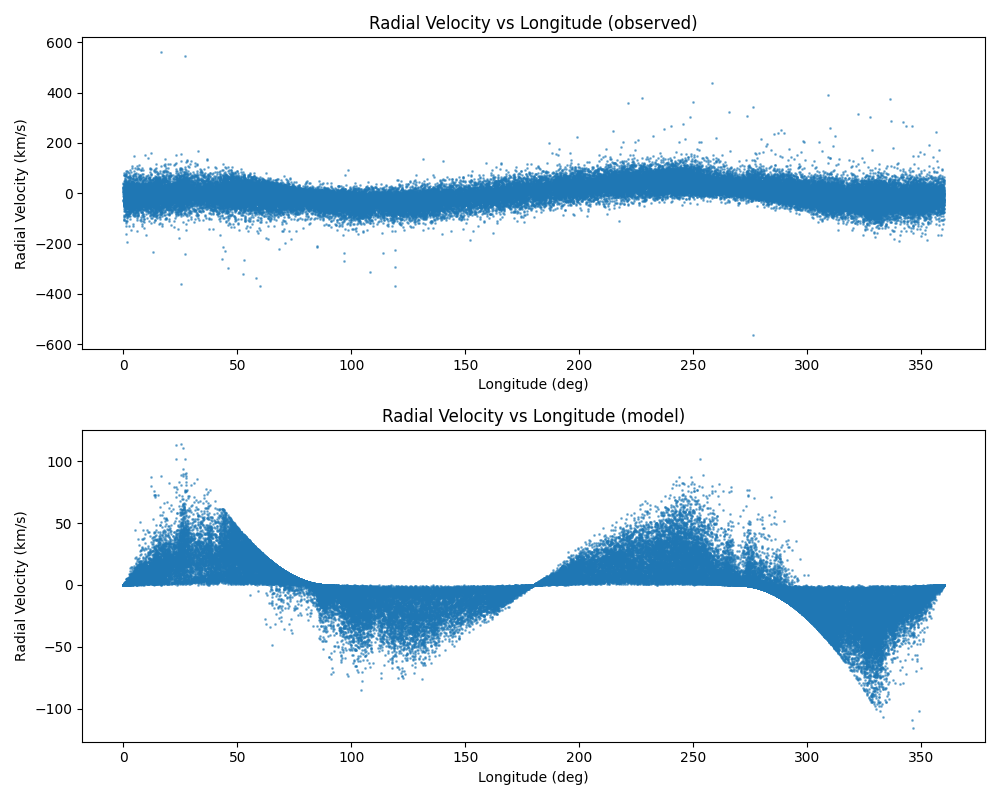

In [121]:
# plot the actual vs expected radial velocities for some initial guess of the parameters
# the lsr term for now is 0

V_rot = 200.0 # km/s
U0 = 0.0 # km/s
V0 = 0.0 # km/s

V_rad_exp = velocity_model(l_rad, d_from_sun, R0, V_rot, U0, V0)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (observed)")

plt.subplot(2, 1, 2)
plt.scatter(l, V_rad_exp, s=1, label="Expected", alpha=0.5)
plt.xlabel("Longitude (deg)")
plt.ylabel("Radial Velocity (km/s)")
plt.title("Radial Velocity vs Longitude (model)")

plt.tight_layout()

plt.show()

## Statistical analysis

### Probability

In [122]:
def log_likelihood(theta, V_rad, l, d, v_rad_error, parallax_error):
    V_rot, f, U0, V0 = theta

    #print(f"V_rot: {V_rot}, f: {f}, U0: {U0}, V0: {V0}")
    

    R = distance_from_gc(l, d, R0)

    # V_rad as function of V_rot (and l)
    model =  velocity_model(l, d, R0, V_rot, U0, V0)

    sigma2 = v_rad_error**2 + f * (model_derivative(l_rad, R0, V_rot, d, R, parallax) * parallax_error)**2

    if np.any(sigma2 < 0.01):
        return -np.inf

    return -np.sum(np.log(np.sqrt(2.0*np.pi*sigma2)) + (0.5*(V_rad - model)**2)/sigma2)

def log_prior(theta):
    V_rot, f, U0, V0 = theta

    # set the prior to be uniform, but set some bounds on the parameters

    if 0.0 < V_rot < 400.0:
        return 0.0
    
    if 0.0 < f < 1.0:
        return 0.0

    if -50.0 < U0 < 50.0:
        return 0.0
    
    if -50.0 < V0 < 50.0:
        return 0.0

    return -np.inf

def log_probability(theta, V_rad, l, d, v_rad_error, parallax_error):
    log_like = log_likelihood(theta, V_rad, l, d, v_rad_error, parallax_error)
    log_pri = log_prior(theta)

    if not np.isfinite(log_like) or not np.isfinite(log_pri):
        return -np.inf

    return log_like + log_pri

### Max likelyhood

In [ ]:
# initial guess for the parameters
# we set some reasonable start values (well inside the prior bounds), then add some random noise to create the initial positions of the walkers
p0 = [100.0, 0.5, 10, 10] # initial guess for the parameters
pos = p0 + np.array([10.0, 0.2, 5.0, 5.0]) * np.random.randn(40, 4)   # 40 walkers, 4 parameters (V_rot, f, U0, V0)

# number of walkers and dimensions can be inferred from the shape of the pos array
nwal, dim = pos.shape
num_iters = 4000

sampler = emcee.EnsembleSampler(nwal, dim, log_probability, args=(radial_velocity, l_rad, d_from_sun, radial_velocity_error, parallax_error))
sampler.run_mcmc(pos, num_iters, progress=True)

  0%|          | 2/4000 [00:00<26:34,  2.51it/s]

  0%|          | 5/4000 [00:01<26:28,  2.52it/s]

## Post processing

### Burn in

In [ ]:
#tau = sampler.get_autocorr_time()
#burn_in = int(2 * np.max(tau))
#thin = int(0.5 * np.min(tau))

burn_in = 200
thin = 10

samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)

In [ ]:
# dump the samples to a file for later use
np.save(f"samples/gaia_mcmc_samples_{time()}.npy", samples)

In [ ]:
V_rot_mcmc, f_mcmc, U0_mcmc, V0_mcmc = np.percentile(samples, [16, 50, 84], axis=0).T

# extract the best-fit parameters (the median of the posterior distribution) as medians
V_rot_best = V_rot_mcmc[1]
f_best = f_mcmc[1]
U0_best = U0_mcmc[1]
V0_best = V0_mcmc[1]

# extract the uncertainties as the 16th and 84th percentiles (2/3s confidence interval)
V_rot_uncertainty = V_rot_mcmc[0] - V_rot_mcmc[2]
f_uncertainty = f_mcmc[0] - f_mcmc[2]
U0_uncertainty = U0_mcmc[0] - U0_mcmc[2]
V0_uncertainty = V0_mcmc[0] - V0_mcmc[2]

# print the best values
print(f"Best-fit V_rot: {V_rot_best:.2f} km/s ± {V_rot_uncertainty:.2f} km/s")
print(f"Best-fit f: {f_best:.2f} ± {f_uncertainty:.2f}")
print(f"Best-fit U0: {U0_best:.2f} ± {U0_uncertainty:.2f}")
print(f"Best-fit V0: {V0_best:.2f} ± {V0_uncertainty:.2f}")

Best-fit V_rot: 1062.55 km/s ± -15148.11 km/s
Best-fit f: 509322.45 ± -2935844.66
Best-fit U0: -0.05 ± -0.08
Best-fit V0: 0.00 ± -0.00


### Corner plot

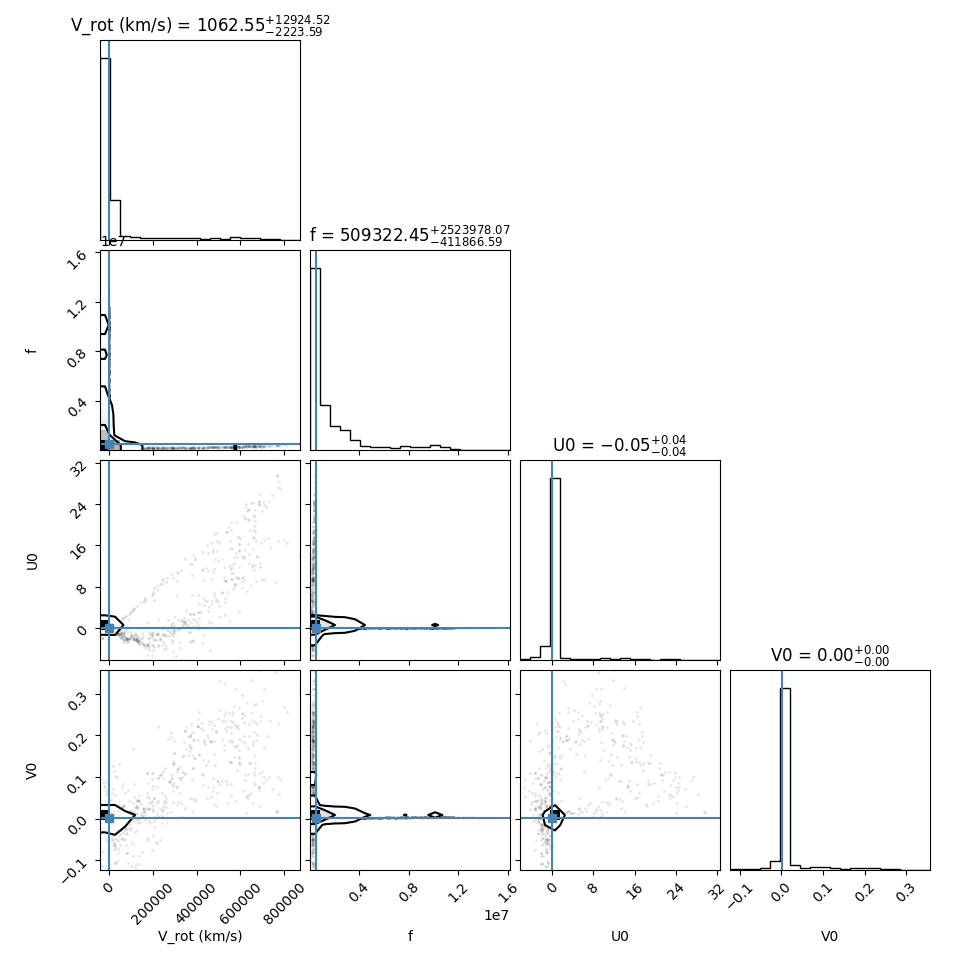

In [ ]:
fig = corner.corner(
    samples, 
    labels=["V_rot (km/s)", "f", "U0", "V0"], 
    truths=[V_rot_best, f_best, U0_best, V0_best], 
    show_titles=True
)

### Trace plot

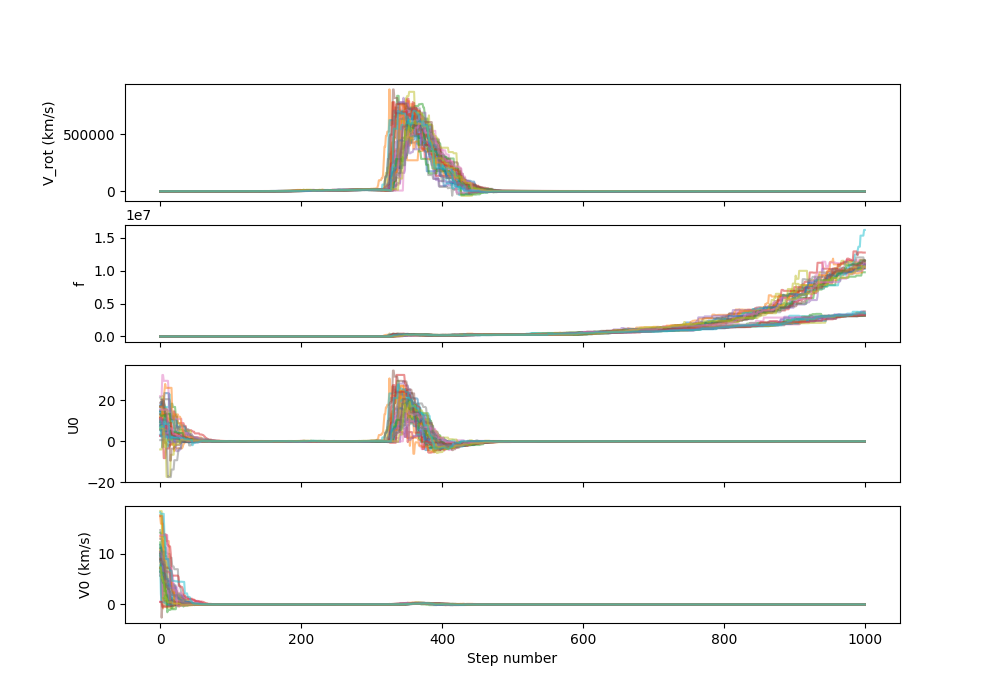

In [ ]:
# trace plot to check for convergence for both parameters
fig, axes = plt.subplots(dim, figsize=(10, 7), sharex=True)
samples_chain = sampler.get_chain()

parameter_labels = ["V_rot (km/s)", "f", "U0", "V0 (km/s)"]

for i in range(dim):
    ax = axes[i]
    for walker in range(nwal):
        ax.plot(samples_chain[:, walker, i], alpha=0.5)
    ax.set_ylabel(f"{parameter_labels[i]}")

axes[-1].set_xlabel("Step number")

plt.show()

### Comparison

/tmp/ipykernel_6149/1226985902.py:32: RuntimeWarning: invalid value encountered in divide
  V_lsr_term = (U0 / np.cos(l_rad)) + (V0 / np.sin(l_rad))


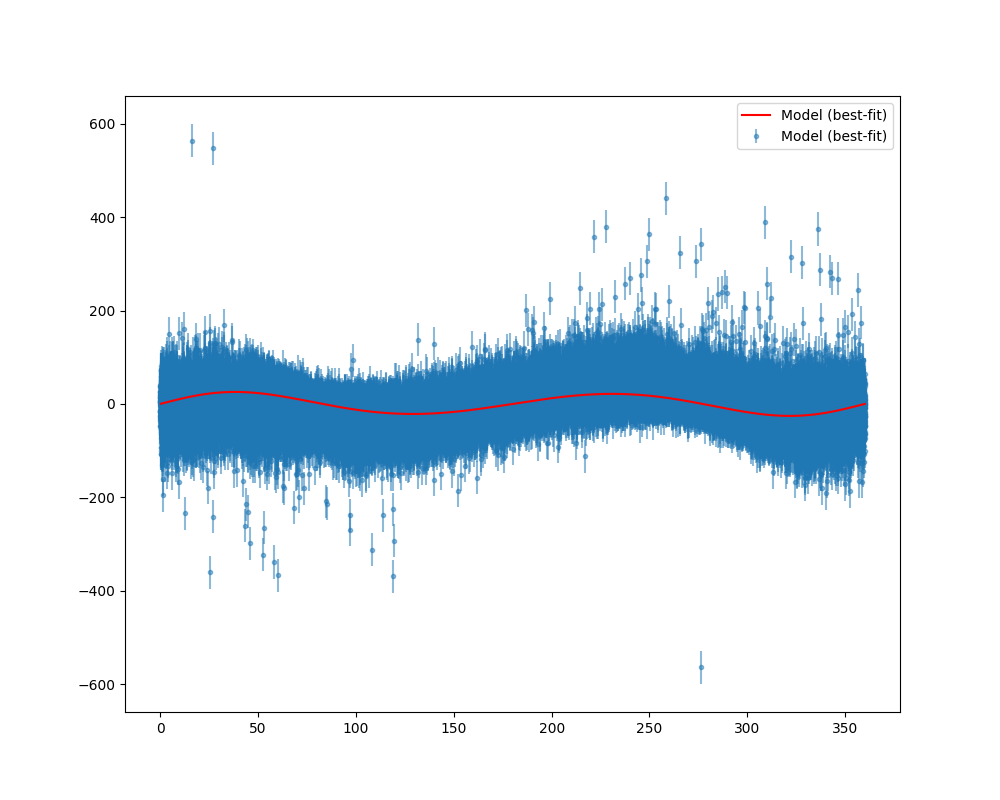

In [ ]:
fig = plt.figure(figsize=(10, 8))

# plot the observed data
#plt.scatter(l, radial_velocity, s=1, label="Observed", alpha=0.5)
sigma = np.sqrt(sigma_rot_best**2 + radial_velocity_error**2)    # total uncertainty (model + measurement)
plt.errorbar(l, radial_velocity, yerr=sigma, fmt='.', label="Model (best-fit)", zorder=1, alpha=0.5)


# plot the model with the best-fit parameters

avg_dist_from_sun = np.mean(d_from_sun)

l_vals_vals = np.linspace(0, 2*np.pi, 1000)
l_vals_deg = np.degrees(l_vals_vals)
V_rad_vals = velocity_model(l_vals_vals, avg_dist_from_sun, R0, V_rot_best, 0.0, 0.0)
plt.plot(l_vals_deg, V_rad_vals, label="Model (best-fit)", color="red", zorder=2)

plt.legend()
plt.show()

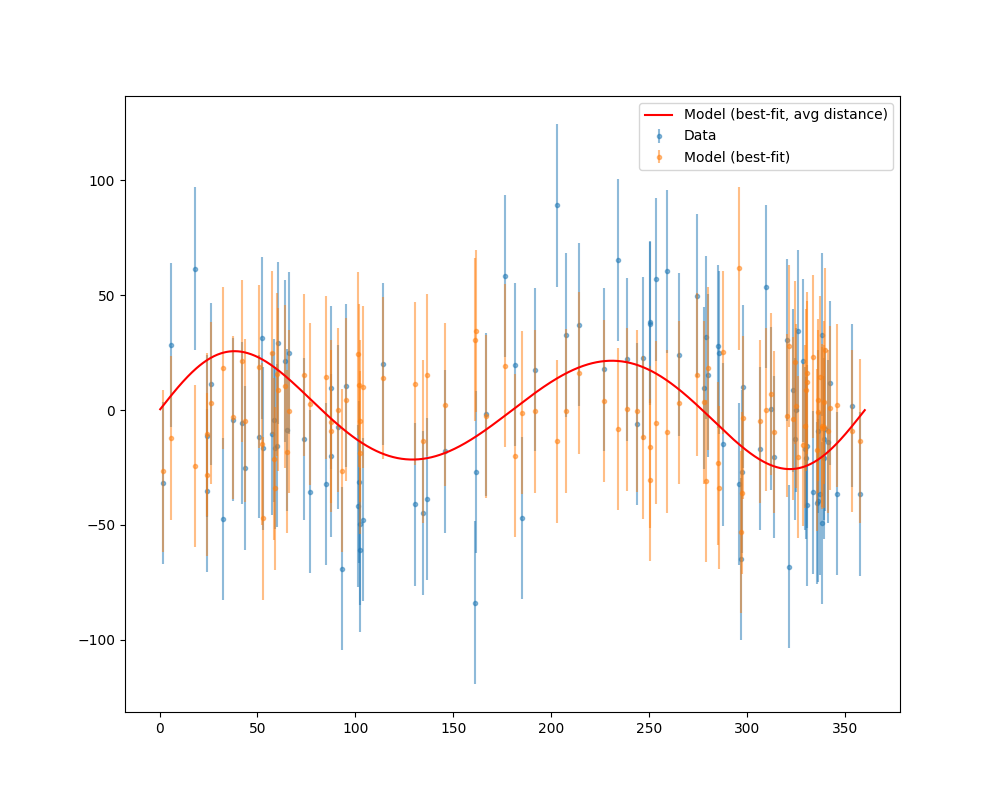

In [ ]:
# extract a random subset of the data

n_samples = 100
indices = np.random.choice(len(d_from_sun), size=n_samples, replace=False)
l_subset = l[indices]
radial_velocity_subset = radial_velocity[indices]
radial_velocity_error_subset = radial_velocity_error[indices]
d_from_sun_subset = d_from_sun[indices]
sigma_subset = np.sqrt(sigma_rot_best**2 + radial_velocity_error_subset**2)    # total uncertainty (model + measurement)

plt.figure(figsize=(10, 8))
plt.errorbar(l_subset, radial_velocity_subset, yerr=sigma_subset, fmt='.', label="Data", zorder=1, alpha=0.5)
plt.errorbar(l_subset, velocity_model(l_subset, d_from_sun_subset, R0, V_rot_best, 0, 0), yerr=sigma_subset, fmt='.', label="Model (best-fit)", zorder=2, alpha=0.5)
plt.plot(l_vals_deg, V_rad_vals, label="Model (best-fit, avg distance)", color="red", zorder=3)
plt.legend()
plt.show()